# Trucking Fleet Analysis
Charts for the key findings, built from the SQL queries in sql/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [2]:
conn = sqlite3.connect('../data/trucking.db')

In [3]:
query = open('../sql/04_profit_after_fuel_by_route.sql').read()

In [4]:
df_profit = pd.read_sql(query, conn)

In [5]:
df_profit

,route_id,origin_city,origin_state,destination_city,destination_state,avg_dist,num_loads,rev_all_per_mi,fuel_cost_per_mi,profit_after_fuel_per_mi
0,RTE00015,Philadelphia,PA,New York,NY,94.26,1537,3.62,0.61,3.01
1,RTE00036,Las Vegas,NV,Los Angeles,CA,269.40,1522,3.13,0.60,2.53
2,RTE00033,Portland,OR,Seattle,WA,171.47,1491,3.02,0.60,2.41
3,RTE00048,Columbus,OH,Portland,OR,2400.81,1525,2.98,0.60,2.38
4,RTE00044,Charlotte,NC,Portland,OR,2707.78,1410,2.94,0.61,2.34
5,RTE00041,Minneapolis,MN,Houston,TX,1251.38,1429,2.94,0.61,2.33
6,RTE00038,Las Vegas,NV,Kansas City,MO,1351.16,1425,2.91,0.60,2.31
7,RTE00046,Columbus,OH,Los Angeles,CA,2335.74,1534,2.90,0.61,2.29
8,RTE00012,Phoenix,AZ,Philadelphia,PA,2459.69,1507,2.84,0.60,2.24
9,RTE00049,Columbus,OH,Minneapolis,MN,739.74,1461,2.84,0.60,2.23


In [6]:
df_profit['lane'] = df_profit['origin_city'] + ' to ' + df_profit['destination_city']

In [7]:
df_profit.head()

,route_id,origin_city,origin_state,destination_city,destination_state,avg_dist,num_loads,rev_all_per_mi,fuel_cost_per_mi,profit_after_fuel_per_mi,lane
0,RTE00015,Philadelphia,PA,New York,NY,94.26,1537,3.62,0.61,3.01,Philadelphia to New York
1,RTE00036,Las Vegas,NV,Los Angeles,CA,269.40,1522,3.13,0.60,2.53,Las Vegas to Los Angeles
2,RTE00033,Portland,OR,Seattle,WA,171.47,1491,3.02,0.60,2.41,Portland to Seattle
3,RTE00048,Columbus,OH,Portland,OR,2400.81,1525,2.98,0.60,2.38,Columbus to Portland
4,RTE00044,Charlotte,NC,Portland,OR,2707.78,1410,2.94,0.61,2.34,Charlotte to Portland


In [8]:
top10 = df_profit.head(10)

## 1. Which lanes to prioritize

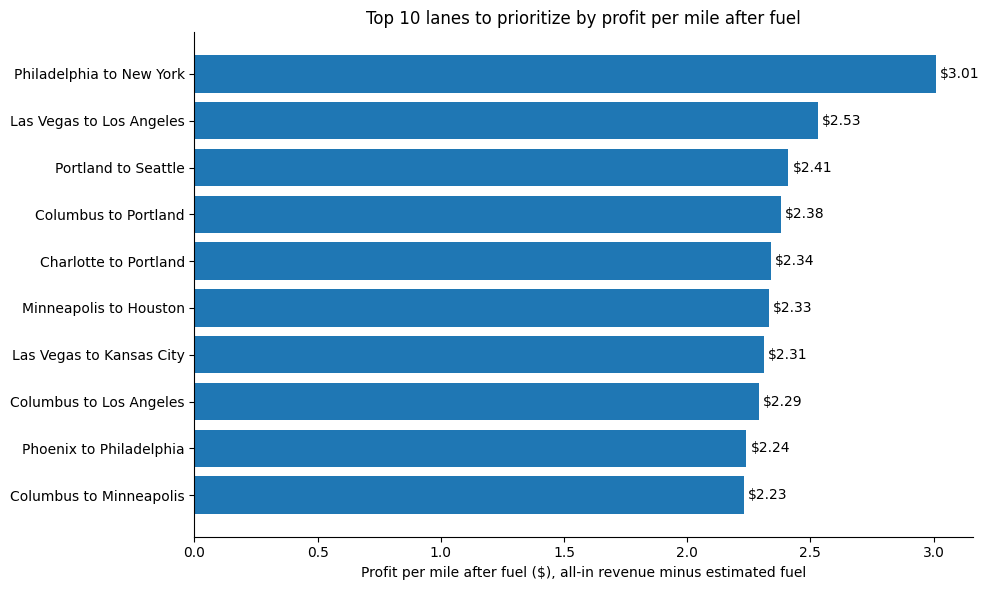

In [9]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top10['lane'], top10['profit_after_fuel_per_mi'])
plt.bar_label(bars, fmt='$%.2f', padding=3)
plt.gca().invert_yaxis()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title('Top 10 lanes to prioritize by profit per mile after fuel')
plt.xlabel('Profit per mile after fuel ($), all-in revenue minus estimated fuel')
plt.tight_layout()
plt.savefig('../output/01_profit_by_lane.png', dpi=150)
plt.show()

## 2. Detention isn't being billed

In [10]:
df_det = pd.read_sql(open('../sql/05d_detention_billing_check.sql').read(), conn)
df_det['detention_type'] = df_det['detention_type'].map({'Billable': 'Past 2-hr free time', 'free': 'Within free time'})
df_det

,count(*),avg_det_mins,avg_acc_fee,detention_type
0,37856,179.966584,71.446402,Past 2-hr free time
1,47554,48.199500,71.801005,Within free time


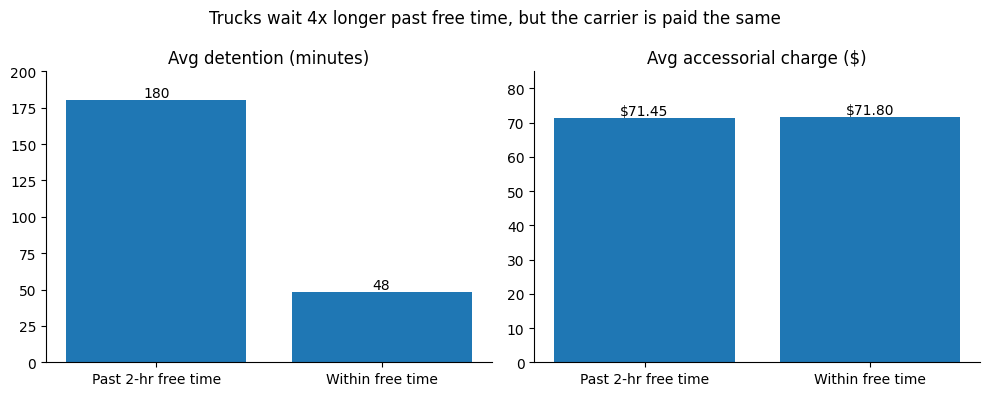

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax in (ax1, ax2): ax.spines[['top', 'right']].set_visible(False)
bars1 = ax1.bar(df_det['detention_type'], df_det['avg_det_mins'])
ax1.set_title('Avg detention (minutes)')
ax1.bar_label(bars1, fmt='%.0f')
bars2 = ax2.bar(df_det['detention_type'], df_det['avg_acc_fee'])
ax2.set_title('Avg accessorial charge ($)')
ax2.bar_label(bars2, fmt='$%.2f')
fig.suptitle('Trucks wait 4x longer past free time, but the carrier is paid the same')
ax1.set_ylim(0, 200)
ax2.set_ylim(0, 85)
plt.tight_layout()
plt.savefig('../output/02_detention_not_billed.png', dpi=150)
plt.show()

## 3. Why fuel purchases don't match fuel used

In [12]:
df_fuel = pd.read_sql(open('../sql/03b_fuel_gap_by_distance_band.sql').read(), conn)
df_fuel

,dist_band,total_miles,count_trips,avg_fuel_gal_used,avg_purchased_gal,ratio_fuel_used
0,0-200,485495,4051,18.60,322.10,0.06
1,201-500,882629,2436,56.12,315.89,0.18
2,501-1000,16286319,22865,110.26,317.77,0.35
3,1001-1500,17735073,14053,195.90,318.05,0.62
4,1501-2000,18253713,10486,269.86,320.85,0.84
5,2001-2500,32850842,14596,349.60,318.27,1.10
6,2501-3000,19253428,7140,417.87,319.20,1.31
7,>3000,4239254,1312,502.70,320.39,1.57


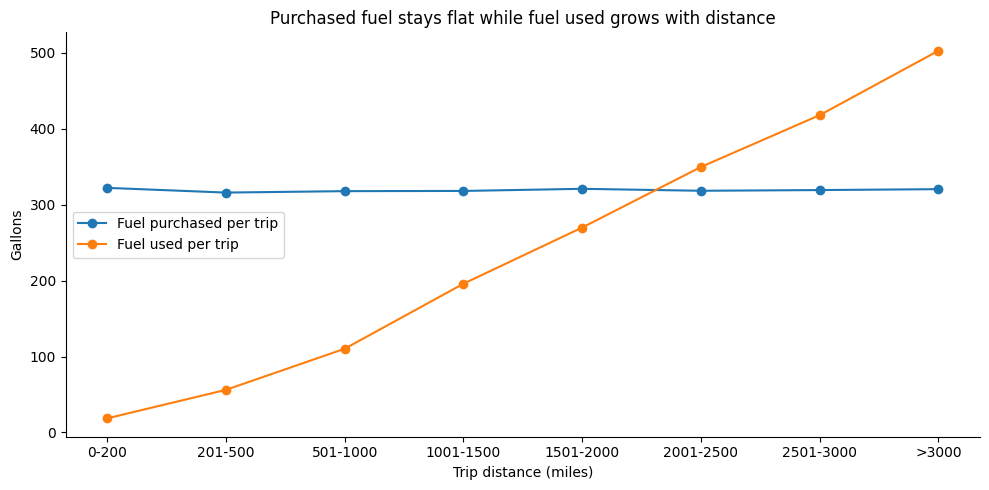

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(df_fuel['dist_band'], df_fuel['avg_purchased_gal'], marker='o', label='Fuel purchased per trip')
plt.plot(df_fuel['dist_band'], df_fuel['avg_fuel_gal_used'], marker='o', label='Fuel used per trip')
plt.legend()
plt.legend(loc='center left')
plt.title('Purchased fuel stays flat while fuel used grows with distance')
plt.xlabel('Trip distance (miles)')
plt.ylabel('Gallons')
plt.tight_layout()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.savefig('../output/03_fuel_gap_by_distance.png', dpi=150)
plt.show()